In [1]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2,FasterRCNN_ResNet50_FPN_V2_Weights
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as F


## Download Pretrained Model & Loading

In [2]:
def load_model():
    weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model=fasterrcnn_resnet50_fpn_v2(weights=weights,box_score_thresh=0.7)
    model.eval()
    return model,weights.meta['categories']

## Image processing

In [3]:
def preprocess_image(image_path):
    image=Image.open(image_path).convert('RGB')
    image_tensor=F.to_tensor(image)
    return image,image_tensor

## Model prediction

In [4]:
def perform_detection(model,image_tensor):
    with torch.no_grad():
        prediction=model([image_tensor])
    print('Model output')
    print(prediction)
    return prediction[0]# first and only prediction

class labels, confidence score, bounding box coordinates

## adding bounding box to our results for visualization

In [ ]:
def visualize_detections(image,prediction,category_names):
    # convert pil image to np for opencv usage
    image_np=np.array(image)
    image_np=cv2.cvtColor(image_np,cv2.COLOR_RGB2BGR)
    #get the prediction components
    boxes=prediction['boxes'].cpu().numpy().astype(np.int32)
    scores=prediction['scores'].cpu().numpy()
    labels=prediction['labels'].cpu().numpy()

    image_with_boxes=image_np.copy()
    color_map={}

    for box,score,label in zip(boxes,scores,labels):
        if label not in color_map:
            color_map[label]=(
                np.random.randint(0,255),
                np.random.randint(0,255),
                np.random.randint(0,255)
            )
        color=color_map[label]
        cv2.rectangle(image_with_boxes,(box[0],box[1]),(box[2],box[3]),color,2)
        label_text=f'{category_names[label]}: {score:.2f}'
        text_size,baseline=cv2.getTextSize(label_text,cv2.FONT_HERSHEY_SIMPLEX,0.5,1)
        cv2.rectangle(image_with_boxes,
                      (box[0],box[1]-text_size[1]-5),
                      (box[0]+text_size[0],box[1]),
                      color,-1)
        cv2.putText(image_with_boxes,label_text,(box[0],box[1]-5),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1,cv2.LINE_AA)
    image_with_boxes=cv2.cvtColor(image_with_boxes,cv2.COLOR_BGR2RGB)
    return image_with_boxes

In [6]:
def main(image_path):
    model,categories=load_model()
    print(f'model loaded with {len(categories)} categories')

    image,image_tensor=preprocess_image(image_path)

    prediction=perform_detection(model,image_tensor)

    num_detection=len(prediction['boxes'])
    print(f'detected {num_detection} objects')

    result_image=visualize_detections(image,prediction,categories)

    #display
    plt.figure(figsize=(12,8))
    plt.imshow(result_image)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    


In [7]:
import os
os.getcwd()

'c:\\Users\\ragha\\OneDrive\\Desktop\\CV COURSE\\objectDetection'

model loaded with 91 categories
Model output
[{'boxes': tensor([[238.1042, 383.3441, 419.4732, 579.6646],
        [389.1893,  59.8964, 727.8726, 543.0201],
        [ 62.1606,  12.6623, 250.7695, 534.2466],
        [257.9053, 268.8411, 409.3015, 576.5536]]), 'labels': tensor([18, 19, 19,  1]), 'scores': tensor([0.9993, 0.9993, 0.9986, 0.9768])}]
detected 4 objects


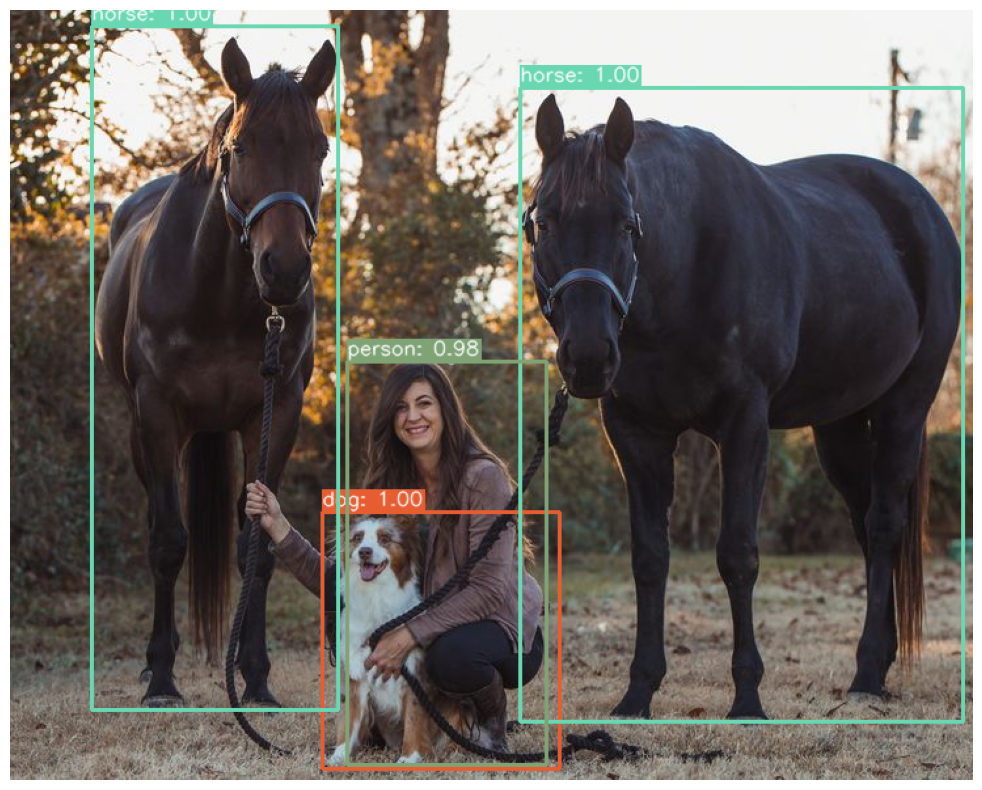

In [11]:
main('images/horses.jpg')